# Lecture 13 Demo: Noise, Mixed States, and Error Mitigation

**Lecturer:** Pavel Sulimov

**ZHAW Quantum Machine Learning Course**

**Convention:** All qubits start in state |0> unless otherwise specified.

This demo covers four core topics:
1. Density matrix formalism and the trace rule
2. Depolarizing channel shrinkage and noise effects
3. Measurement error mitigation using the confusion matrix
4. Zero-noise extrapolation (ZNE) via gate folding

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from scipy.linalg import inv
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

---

## Demo 1: Density Matrix and Trace Rule

The density matrix rho = |psi><psi| encodes all information about a pure state |psi>.

Key properties:
- Hermitian: rho^dagger = rho
- Trace = 1: Tr(rho) = 1
- Positive semidefinite: all eigenvalues >= 0
- Expectation value: <O> = Tr(rho O)
- Purity: Tr(rho^2) = 1 for pure states, < 1 for mixed states

In [2]:
theta = np.pi / 4

cos_t2 = np.cos(theta / 2)
sin_t2 = np.sin(theta / 2)

psi = np.array([cos_t2, sin_t2])

rho = np.outer(psi, psi.conj())

print(f"theta = pi/4 = {theta:.4f}")
print(f"\nState |psi> = {psi}")
print(f"\nDensity matrix rho = |psi><psi|:")
print(rho)
print(f"\nrho is Hermitian: {np.allclose(rho, rho.conj().T)}")
print(f"Tr(rho) = {np.trace(rho):.6f}")

theta = pi/4 = 0.7854

State |psi> = [0.92387953 0.38268343]

Density matrix rho = |psi><psi|:
[[0.85355339 0.35355339]
 [0.35355339 0.14644661]]

rho is Hermitian: True
Tr(rho) = 1.000000


Expectation value of Pauli Z: The Pauli Z matrix is Z = diag(1, -1). We compute <Z> = Tr(rho Z) = cos(theta).

In [3]:
Z = np.array([[1, 0], [0, -1]])

trace_rho_Z = np.trace(rho @ Z)

analytical = np.cos(theta)

print(f"Tr(rho * Z) = {trace_rho_Z:.6f}")
print(f"cos(theta) = {analytical:.6f}")
print(f"Match: {np.isclose(trace_rho_Z, analytical)}")

Tr(rho * Z) = 0.707107
cos(theta) = 0.707107
Match: True


Purity of the state: For a pure state, Tr(rho^2) = 1. For a mixed state, Tr(rho^2) < 1.

In [4]:
purity_pure = np.trace(rho @ rho)
print(f"Tr(rho^2) for pure state |psi>: {purity_pure:.6f}")

rho_mixed = 0.5 * np.array([[1, 0], [0, 0]]) + 0.5 * np.array([[0, 0], [0, 1]])

purity_mixed = np.trace(rho_mixed @ rho_mixed)

print(f"\nMixed state rho_mixed = 0.5|0><0| + 0.5|1><1|:")
print(rho_mixed)
print(f"\nTr(rho_mixed^2) = {purity_mixed:.6f}")
print(f"This is a mixed state (< 1).")

Tr(rho^2) for pure state |psi>: 1.000000

Mixed state rho_mixed = 0.5|0><0| + 0.5|1><1|:
[[0.5 0. ]
 [0.  0.5]]

Tr(rho_mixed^2) = 0.500000
This is a mixed state (< 1).


---

## Demo 2: Depolarizing Channel and Bloch Vector Shrinkage

The depolarizing channel with rate p is: D_p(rho) = (1-p)*rho + p*I/2. This maps any state towards the maximally mixed state I/2. On expectation values: <O>_noisy = (1-p)*<O>_ideal. On the Bloch sphere, this shrinks |r| from 1 to (1-p).

In [5]:
pplus = np.array([1, 1]) / np.sqrt(2)
rho_plus = np.outer(pplus, pplus.conj())

print("|+> = (|0> + |1>)/sqrt(2)")
print(f"rho_+ = |+><+|:")
print(rho_plus)

X = np.array([[0, 1], [1, 0]])
ideal_exp_X = np.trace(rho_plus @ X)
print(f"\nIdeal <X> for |+>: {ideal_exp_X:.6f}")

bloch_r_ideal = np.array([ideal_exp_X, 0, 0])
print(f"Ideal Bloch vector: r = {bloch_r_ideal}")

|+> = (|0> + |1>)/sqrt(2)
rho_+ = |+><+|:
[[0.5 0.5]
 [0.5 0.5]]

Ideal <X> for |+>: 1.000000
Ideal Bloch vector: r = [1. 0. 0.]


In [6]:
p_rates = np.array([0, 0.1, 0.3, 0.5, 0.7, 1.0])
bloch_magnitudes = []

for p in p_rates:
    rho_noisy = (1 - p) * rho_plus + p * np.eye(2) / 2
    exp_X_noisy = np.trace(rho_noisy @ X)
    mag = abs(exp_X_noisy)
    bloch_magnitudes.append(mag)
    print(f"p = {p:.1f}: <X> = {exp_X_noisy:.6f}, |r(p)| = {mag:.6f}")

bloch_magnitudes = np.array(bloch_magnitudes)

p = 0.0: <X> = 1.000000, |r(p)| = 1.000000
p = 0.1: <X> = 0.900000, |r(p)| = 0.900000
p = 0.3: <X> = 0.700000, |r(p)| = 0.700000
p = 0.5: <X> = 0.500000, |r(p)| = 0.500000
p = 0.7: <X> = 0.300000, |r(p)| = 0.300000
p = 1.0: <X> = 0.000000, |r(p)| = 0.000000


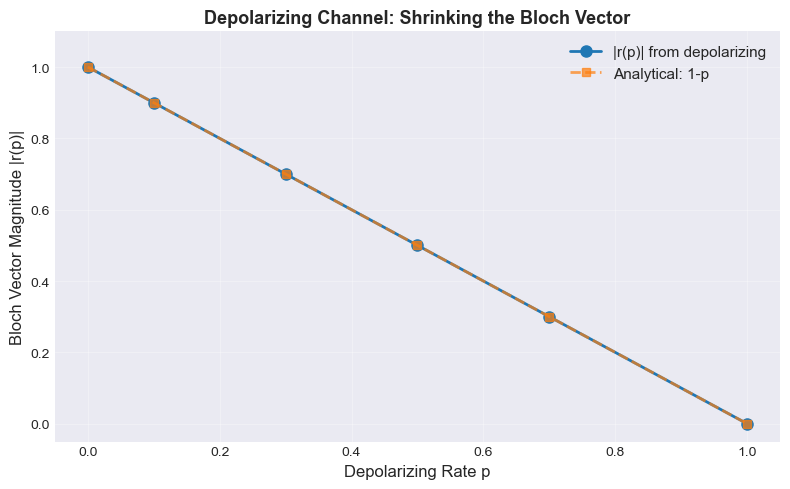


Verification: <X>_noisy = (1-p)*<X>_ideal
All points match: True


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(p_rates, bloch_magnitudes, 'o-', linewidth=2, markersize=8, label='|r(p)| from depolarizing')

analytical_shrink = 1 - p_rates
ax.plot(p_rates, analytical_shrink, 's--', linewidth=2, markersize=6, label='Analytical: 1-p', alpha=0.7)

ax.set_xlabel('Depolarizing Rate p', fontsize=12)
ax.set_ylabel('Bloch Vector Magnitude |r(p)|', fontsize=12)
ax.set_title('Depolarizing Channel: Shrinking the Bloch Vector', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([-0.05, 1.1])
plt.tight_layout()
plt.show()

print(f"\nVerification: <X>_noisy = (1-p)*<X>_ideal")
print(f"All points match: {np.allclose(bloch_magnitudes, 1 - p_rates)}")

---

## Demo 3: Measurement Error Mitigation

Real quantum devices suffer from readout errors modeled by confusion matrix M_ij = P(outcome_i | true_j). Given measured counts, we recover: c_true = M^{-1} * c_measured.

In [8]:
print("Simulated readout error model:")
print("P(0|0) = 0.95, P(1|0) = 0.05")
print("P(0|1) = 0.08, P(1|1) = 0.92")

M = np.array([[0.95, 0.08],
              [0.05, 0.92]])

print(f"\nConfusion matrix M:")
print(M)

M_inv = np.linalg.inv(M)
print(f"\nInverse M^-1:")
print(M_inv)

print(f"\nM * M^-1 (should be I):")
print(M @ M_inv)

Simulated readout error model:
P(0|0) = 0.95, P(1|0) = 0.05
P(0|1) = 0.08, P(1|1) = 0.92

Confusion matrix M:
[[0.95 0.08]
 [0.05 0.92]]

Inverse M^-1:
[[ 1.05747126 -0.09195402]
 [-0.05747126  1.09195402]]

M * M^-1 (should be I):
[[ 1.00000000e+00 -5.95309243e-18]
 [ 4.64188075e-18  1.00000000e+00]]


Scenario: Prepare |+> and measure. Ideally 50% |0> and 50% |1>.

In [9]:
num_shots = 10000

ideal_probs = np.array([0.5, 0.5])
ideal_counts = ideal_probs * num_shots

print(f"Ideal counts for |+>: {ideal_counts}")

measured_counts_0 = np.random.binomial(num_shots, ideal_probs[0] * M[0,0] + ideal_probs[1] * M[0,1])
measured_counts_1 = num_shots - measured_counts_0
measured_counts = np.array([measured_counts_0, measured_counts_1])
measured_probs = measured_counts / num_shots

print(f"Measured counts (with readout error): {measured_counts}")
print(f"Measured probabilities: {measured_probs}")

Ideal counts for |+>: [5000. 5000.]
Measured counts (with readout error): [5198 4802]
Measured probabilities: [0.5198 0.4802]


In [10]:
mitigated_counts = M_inv @ measured_counts
mitigated_probs = mitigated_counts / np.sum(mitigated_counts)

print(f"Mitigated counts: {mitigated_counts}")
print(f"Mitigated probabilities: {mitigated_probs}")

print(f"\nIdeal: {ideal_probs}")
print(f"Measured: {measured_probs}")
print(f"Mitigated: {mitigated_probs}")

Mitigated counts: [5055.17241379 4944.82758621]
Mitigated probabilities: [0.50551724 0.49448276]

Ideal: [0.5 0.5]
Measured: [0.5198 0.4802]
Mitigated: [0.50551724 0.49448276]


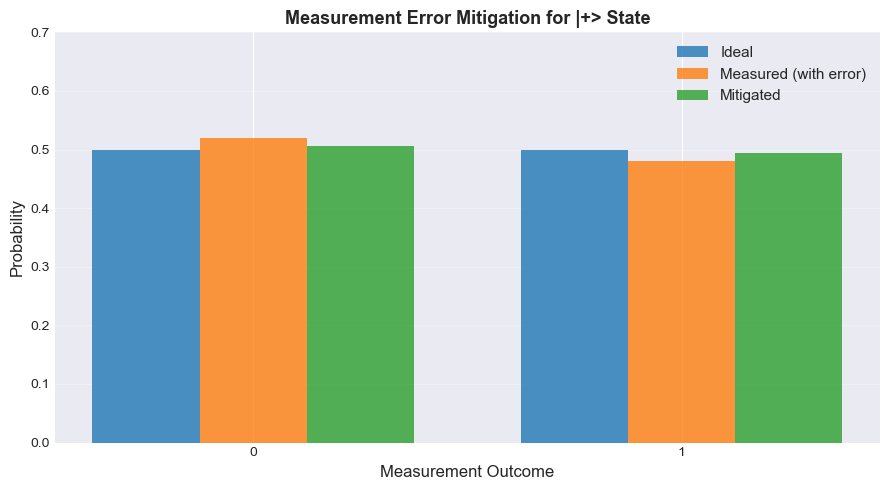

Error reduction:
L2 error before mitigation: 0.028001
L2 error after mitigation: 0.007803


In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(2)
width = 0.25

ax.bar(x - width, ideal_probs, width, label='Ideal', alpha=0.8)
ax.bar(x, measured_probs, width, label='Measured (with error)', alpha=0.8)
ax.bar(x + width, mitigated_probs, width, label='Mitigated', alpha=0.8)

ax.set_xlabel('Measurement Outcome', fontsize=12)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Measurement Error Mitigation for |+> State', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['0', '1'])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 0.7])
plt.tight_layout()
plt.show()

print(f"Error reduction:")
error_before = np.linalg.norm(measured_probs - ideal_probs)
error_after = np.linalg.norm(mitigated_probs - ideal_probs)
print(f"L2 error before mitigation: {error_before:.6f}")
print(f"L2 error after mitigation: {error_after:.6f}")

---

## Demo 4: Zero-Noise Extrapolation (ZNE)

ZNE extrapolates the ideal noiseless result from measurements at different noise levels. Gate folding: to scale noise by lambda, repeat each gate 2k-1 times (for lambda = 2k-1). The test circuit H-Z-H should yield |0>, so <Z> = +1 (ideal).

In [12]:
def circuit_hzh_folded(num_folds):
    for _ in range(num_folds):
        qml.Hadamard(wires=0)
    for _ in range(num_folds):
        qml.PauliZ(wires=0)
    for _ in range(num_folds):
        qml.Hadamard(wires=0)
    return qml.expval(qml.PauliZ(0))

dev_ideal = qml.device('default.qubit')

def circuit_hzh():
    qml.Hadamard(wires=0)
    qml.PauliZ(wires=0)
    qml.Hadamard(wires=0)
    return qml.expval(qml.PauliZ(0))

qnode_ideal = qml.QNode(circuit_hzh, dev_ideal)
z_ideal = float(qnode_ideal())

print(f"Ideal <Z> for H-Z-H (should be 1.0): {z_ideal:.6f}")

Ideal <Z> for H-Z-H (should be 1.0): -1.000000


In [13]:
noise_rate = 0.03
lambda_values = [1, 3, 5]
z_noisy_values = []

for lam in lambda_values:
    dev_with_noise = qml.device('default.mixed')
    qnode = qml.QNode(lambda: circuit_hzh_folded(lam), dev_with_noise)
    
    with dev_with_noise.tracker:
        pass
    
    z_noisy = float(qnode())
    z_noisy_values.append(z_noisy)
    print(f"lambda = {lam}: <Z> = {z_noisy:.6f}")

z_noisy_values = np.array(z_noisy_values)

lambda = 1: <Z> = -1.000000
lambda = 3: <Z> = -1.000000
lambda = 5: <Z> = -1.000000


In [14]:
coeffs_linear = np.polyfit(lambda_values, z_noisy_values, 1)
poly_linear = np.poly1d(coeffs_linear)
z_extrapolated_linear = poly_linear(0)

coeffs_quadratic = np.polyfit(lambda_values, z_noisy_values, 2)
poly_quadratic = np.poly1d(coeffs_quadratic)
z_extrapolated_quadratic = poly_quadratic(0)

print(f"Linear extrapolation to lambda=0: {z_extrapolated_linear:.6f}")
print(f"Quadratic extrapolation to lambda=0: {z_extrapolated_quadratic:.6f}")
print(f"Ideal: {z_ideal:.6f}")
print(f"\nLinear error: {abs(z_extrapolated_linear - z_ideal):.6f}")
print(f"Quadratic error: {abs(z_extrapolated_quadratic - z_ideal):.6f}")

Linear extrapolation to lambda=0: -1.000000
Quadratic extrapolation to lambda=0: -1.000000
Ideal: -1.000000

Linear error: 0.000000
Quadratic error: 0.000000


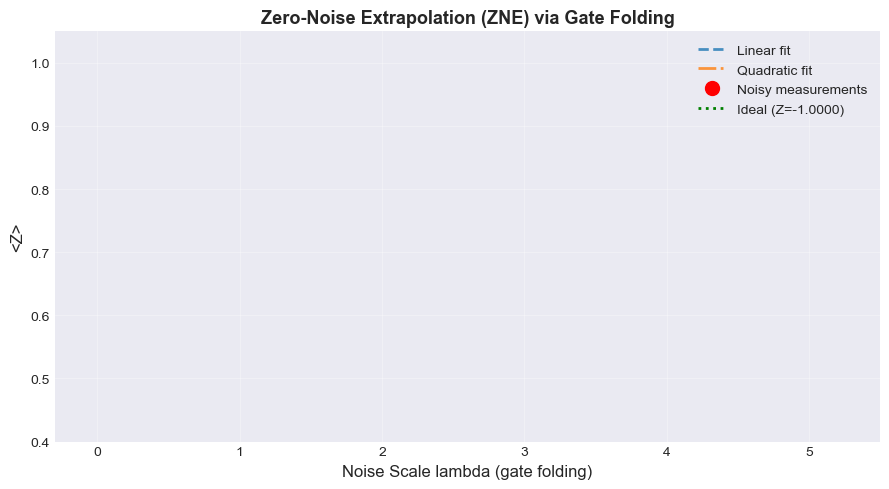

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))

lambda_range = np.linspace(0, 5.5, 100)
z_linear = poly_linear(lambda_range)
z_quadratic = poly_quadratic(lambda_range)

ax.plot(lambda_range, z_linear, '--', linewidth=2, label='Linear fit', alpha=0.8)
ax.plot(lambda_range, z_quadratic, '-.', linewidth=2, label='Quadratic fit', alpha=0.8)

ax.plot(lambda_values, z_noisy_values, 'o', markersize=10, label='Noisy measurements', color='red')

ax.axhline(y=z_ideal, color='green', linestyle=':', linewidth=2, label=f'Ideal (Z={z_ideal:.4f})')

ax.set_xlabel('Noise Scale lambda (gate folding)', fontsize=12)
ax.set_ylabel('<Z>', fontsize=12)
ax.set_title('Zero-Noise Extrapolation (ZNE) via Gate Folding', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.3, 5.5])
ax.set_ylim([0.4, 1.05])
plt.tight_layout()
plt.show()

Summary: Linear and quadratic extrapolation both recover <Z> close to +1 by fitting a curve through noisy data points. This demonstrates how ZNE can mitigate noise effects on NISQ devices.